# 05 — Monte Carlo (uniform)

Independent **uniform** draws on each $R$, $C$, $V_{OS}$, $I_{B+}$, $I_{B-}$ interval.

| Mode | Default $N$ |
|------|----------------|
| Analytical | 2000 |
| ngspice subset | 40 (increase for production) |

**Metrics**

1. Cutoff $f_c$ (−3 dB)
2. DC accuracy at applied $V_{\mathrm{in,DC}}$: $\varepsilon_{\mathrm{DC}}=V_{\mathrm{out}}-V_{\mathrm{in}}$

Histograms show **MC distribution**, **WC endpoint limits** (red dashed), and
**RSS ±** band (green dash-dot) from the sensitivity stack-up.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Directory that contains opamp_design/. Works when this notebook is run
# from the standalone repo (repo root or notebooks/) or from this website
# section (the folder that holds these notebooks and opamp_design/).
def _find_project_root() -> Path:
    start = Path.cwd().resolve()
    named = Path("Sections/Electronics/Analog_and_Digital/OPA365_Fig86")
    candidates = [start, *start.parents, start / named]
    if start.name == "notebooks":
        candidates.insert(0, start.parent)
    for cand in candidates:
        if (cand / "opamp_design" / "__init__.py").is_file():
            return cand
    return start

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from opamp_design.params import CircuitParams, OpampParams, ToleranceSpec, format_eng
from opamp_design import analysis, schematic

# -----------------------------------------------------------------------------
# EDITABLE PARAMETERS — change R/C/tolerances here for what-if studies.
# For a completely different netlist, keep these as documentation of the
# stimulus/supply and drive opamp_design.simulate.run_external_netlist(...)
# with your own .cir instead of the Fig. 8-6 generators.
# -----------------------------------------------------------------------------
R1 = 1.8e3       # ohms
R2 = 19.5e3
R3 = 150e3
C1 = 3.3e-9      # farads
C2 = 47e-12
C3 = 220e-12
R_TOL = 0.001    # 0.1% as fraction
C_TOL = 0.01     # 1% as fraction
V_SUPPLY = 5.0
V_IN_BIAS = 2.5
V_IN_PEAK = 2.5
F_DESIGN = 20e3
# Applied DC voltage for accuracy analysis (unity-gain: target Vout = Vin)
VIN_DC = 2.5

p = CircuitParams(
    R1=R1, R2=R2, R3=R3, C1=C1, C2=C2, C3=C3,
    r_tol=ToleranceSpec(R_TOL),
    c_tol=ToleranceSpec(C_TOL),
)
from dataclasses import replace
p = replace(p, op=replace(p.op, v_supply=V_SUPPLY, v_in_bias=V_IN_BIAS,
                          v_in_peak=V_IN_PEAK, f_design_hz=F_DESIGN))

FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("ROOT =", ROOT)
print("R1..C3 =", p.passive_dict())
print("VIN_DC for accuracy =", VIN_DC, "V")


ROOT = .
R1..C3 = {'R1': 1800.0, 'R2': 19500.0, 'R3': 150000.0, 'C1': 3.3e-09, 'C2': 4.7e-11, 'C3': 2.2e-10}
VIN_DC for accuracy = 2.5 V


In [2]:
from opamp_design.monte_carlo import sample_metrics, spice_monte_carlo, annotate_wc_rss_on_axis
from opamp_design.worst_case import analytical_worst_case, rss_bounds

N_MC = 2000          # analytical
N_SPICE_MC = 40      # ngspice subset (raise when you have time)
SEED = 42

# WC + RSS reference (same vin_dc / tolerances as notebook 04)
wc = analytical_worst_case(p, include_opamp=True, vin_dc=VIN_DC)
rss = rss_bounds(p, metrics=("fc_hz", "dc_error"), vin_dc=VIN_DC, include_opamp=True)

mc = sample_metrics(p, n=N_MC, seed=SEED, include_opamp=True, vin_dc=VIN_DC)
mc.save(ROOT / "results" / "mc_analytical")
display(mc.summary.loc[["fc_hz", "dc_vout", "dc_error", "dc_error_ppm"]])

print(f"Vin_DC = {VIN_DC} V")
print(f"MC fc:     mean={mc.frame.fc_hz.mean():.2f}  std={mc.frame.fc_hz.std():.2f} Hz")
print(f"WC fc:     [{wc.minimum['fc_hz']:.2f}, {wc.maximum['fc_hz']:.2f}] Hz")
print(f"RSS fc:    [{rss['fc_hz']['low']:.2f}, {rss['fc_hz']['high']:.2f}] Hz")
print(f"MC dc_err: mean={mc.frame.dc_error.mean()*1e6:.2f}  std={mc.frame.dc_error.std()*1e6:.2f} µV")
print(f"WC dc_err: [{wc.minimum['dc_error']*1e6:.2f}, {wc.maximum['dc_error']*1e6:.2f}] µV")
print(f"RSS dc_err:[{rss['dc_error']['low']*1e6:.2f}, {rss['dc_error']['high']*1e6:.2f}] µV")


,mean,std,min,max,p01,p05,p50,p95,p99
fc_hz,1.977266e+04,106.863177,19501.758112,20046.904557,19546.796795,19595.492011,1.977020e+04,19952.406892,19997.614220
dc_vout,2.500001e+00,0.000115,2.499800,2.500201,2.499803,2.499820,2.500001e+00,2.500180,2.500196
dc_error,5.800199e-07,0.000115,-0.000200,0.000201,-0.000197,-0.000180,8.773205e-07,0.000180,0.000196
dc_error_ppm,2.320080e-01,46.063996,-80.105576,80.449648,-78.690471,-71.871443,3.509282e-01,72.152628,78.379346


Vin_DC = 2.5 V
MC fc:     mean=19772.66  std=106.86 Hz
WC fc:     [19550.26, 19990.11] Hz
RSS fc:    [19580.36, 19953.06] Hz
MC dc_err: mean=0.58  std=115.16 µV
WC dc_err: [-201.71, 201.71] µV
RSS dc_err:[-200.01, 200.01] µV


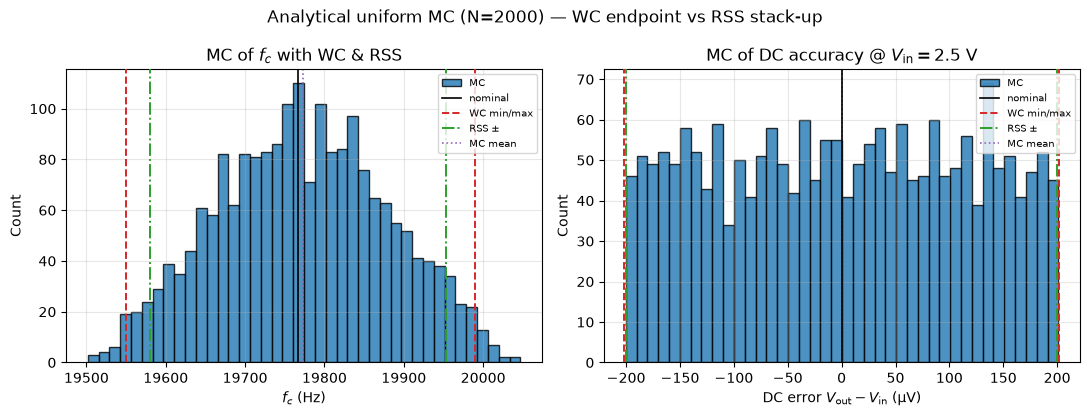

In [3]:
# MC histograms with WC (red --) and RSS (green -.) overlays
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# --- fc ---
ax = axes[0]
ax.hist(mc.frame["fc_hz"].dropna(), bins=40, color="C0", edgecolor="k", alpha=0.8, label="MC")
annotate_wc_rss_on_axis(
    ax,
    wc_low=wc.minimum["fc_hz"],
    wc_high=wc.maximum["fc_hz"],
    rss_low=rss["fc_hz"]["low"],
    rss_high=rss["fc_hz"]["high"],
    nominal=wc.nominal["fc_hz"],
)
ax.axvline(mc.frame["fc_hz"].mean(), color="C4", ls=":", lw=1.2, label="MC mean")
ax.set_xlabel(r"$f_c$ (Hz)")
ax.set_ylabel("Count")
ax.set_title(r"MC of $f_c$ with WC & RSS")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, loc="best")

# --- DC error ---
ax = axes[1]
ax.hist(mc.frame["dc_error"].dropna() * 1e6, bins=40, color="C0", edgecolor="k", alpha=0.8, label="MC")
annotate_wc_rss_on_axis(
    ax,
    wc_low=wc.minimum["dc_error"] * 1e6,
    wc_high=wc.maximum["dc_error"] * 1e6,
    rss_low=rss["dc_error"]["low"] * 1e6,
    rss_high=rss["dc_error"]["high"] * 1e6,
    nominal=wc.nominal["dc_error"] * 1e6,
)
ax.axvline(mc.frame["dc_error"].mean() * 1e6, color="C4", ls=":", lw=1.2, label="MC mean")
ax.set_xlabel(r"DC error $V_{\mathrm{out}}-V_{\mathrm{in}}$ (µV)")
ax.set_ylabel("Count")
ax.set_title(fr"MC of DC accuracy @ $V_{{\mathrm{{in}}}}={VIN_DC:g}$ V")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, loc="best")

fig.suptitle(f"Analytical uniform MC (N={N_MC}) — WC endpoint vs RSS stack-up")
fig.tight_layout()
fig.savefig(FIG / "05_mc_fc_dc_wc_rss.png", dpi=150)
plt.show()


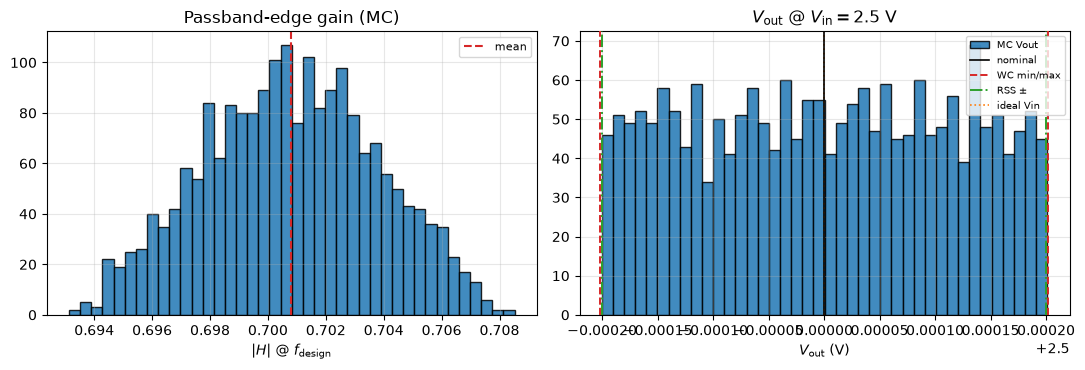

In [4]:
# Secondary: |H|@f_design and Vout histograms (with WC/RSS on Vout via dc path)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
ax.hist(mc.frame["gain_at_fdesign"].dropna(), bins=40, color="C0", edgecolor="k", alpha=0.85)
ax.axvline(mc.frame["gain_at_fdesign"].mean(), color="C3", ls="--", label="mean")
ax.set_xlabel(r"$|H|$ @ $f_{\mathrm{design}}$")
ax.set_title("Passband-edge gain (MC)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(mc.frame["dc_vout"].dropna(), bins=40, color="C0", edgecolor="k", alpha=0.85, label="MC Vout")
# WC/RSS on Vout = Vin + dc_error bounds
annotate_wc_rss_on_axis(
    ax,
    wc_low=VIN_DC + wc.minimum["dc_error"],
    wc_high=VIN_DC + wc.maximum["dc_error"],
    rss_low=VIN_DC + rss["dc_error"]["low"],
    rss_high=VIN_DC + rss["dc_error"]["high"],
    nominal=VIN_DC + wc.nominal["dc_error"],
)
ax.axvline(VIN_DC, color="C1", ls=":", lw=1.2, label="ideal Vin")
ax.set_xlabel(r"$V_{\mathrm{out}}$ (V)")
ax.set_title(fr"$V_{{\mathrm{{out}}}}$ @ $V_{{\mathrm{{in}}}}={VIN_DC:g}$ V")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7)

fig.tight_layout()
fig.savefig(FIG / "05_mc_gain_vout.png", dpi=150)
plt.show()


,mean,std,min,max,p05,p50,p95
fc_spice_hz,19778.866060,1.073249e+02,19577.716918,19970.388453,19624.110727,19788.670191,19904.745789
passband_gain_spice,0.999999,1.324377e-09,0.999999,0.999999,0.999999,0.999999,0.999999


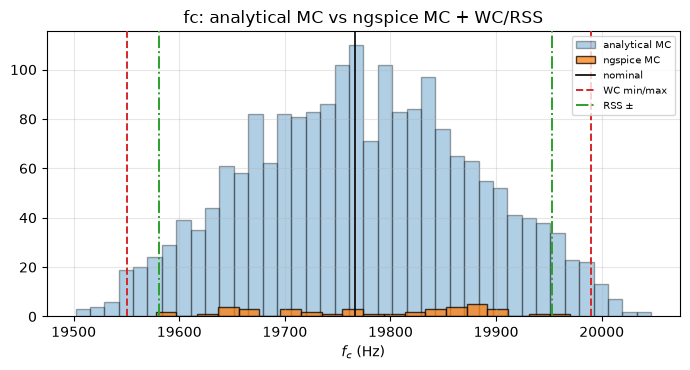

In [5]:
# ngspice MC subset for fc (cached); overlay analytical MC + WC/RSS
try:
    smc = spice_monte_carlo(
        p, n=N_SPICE_MC, seed=SEED,
        workdir=ROOT / "results" / "ngspice_mc",
        root=ROOT, opamp_model="ideal", cache=True,
    )
    display(smc.summary)
    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.hist(mc.frame["fc_hz"], bins=40, alpha=0.35, label="analytical MC", color="C0", edgecolor="k")
    ax.hist(smc.frame["fc_spice_hz"].dropna(), bins=20, alpha=0.75, label="ngspice MC", color="C1", edgecolor="k")
    annotate_wc_rss_on_axis(
        ax,
        wc_low=wc.minimum["fc_hz"],
        wc_high=wc.maximum["fc_hz"],
        rss_low=rss["fc_hz"]["low"],
        rss_high=rss["fc_hz"]["high"],
        nominal=wc.nominal["fc_hz"],
    )
    ax.set_xlabel(r"$f_c$ (Hz)")
    ax.set_title("fc: analytical MC vs ngspice MC + WC/RSS")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG / "05_mc_fc_compare.png", dpi=150)
    plt.show()
except Exception as e:
    print("SPICE MC skipped/failed:", e)
